# RandomForest — Feature Selection

**Prerequisite:** Run `data/01_build_features.ipynb` to generate `data/latest_features.jsonl`.

**Goal:** Find the optimal feature set for RandomForest.

**Method:** Feature importance ranking — train RF on all features, rank by importance, test top-N
to find optimal count. This is fast (O(N) evaluations) and well-suited to tree-based models.

**Metric:** Per-snapshot accuracy (same as LR and XGB notebooks).

**Output:** `data/optimal_features_rf.json` with features and hyperparameters.


In [16]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json as _json
import random
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")

## 1. Load data and train/val split

In [17]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(_json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
train_ids = set(candle_ids[:split_idx])

df_train = df[df["candle_id"].isin(train_ids)]
df_val = df[~df["candle_id"].isin(train_ids)]

scaler = StandardScaler()
X_train_all = scaler.fit_transform(df_train[all_feat_cols].values)
y_train = df_train["target"].values
X_val_all = scaler.transform(df_val[all_feat_cols].values)
y_val = df_val["target"].values

print(f"Features: {len(all_feat_cols)}")
print(f"Train: {len(df_train):,} rows, {df_train['candle_id'].nunique()} candles")
print(f"Val:   {len(df_val):,} rows, {df_val['candle_id'].nunique()} candles")

Features: 60
Train: 53,236 rows, 1100 candles
Val:   12,917 rows, 276 candles


## 2. Baseline — all features

In [18]:
RF_PARAMS = {
    "n_estimators": 200,
    "max_depth": 15,
    "min_samples_leaf": 20,
    "random_state": 42,
    "n_jobs": -1,
}

baseline = RandomForestClassifier(**RF_PARAMS)
baseline.fit(X_train_all, y_train)
baseline_acc = accuracy_score(y_val, baseline.predict(X_val_all))
print(f"Baseline (all {len(all_feat_cols)} features): {baseline_acc * 100:.1f}% snapshot accuracy")

Baseline (all 60 features): 74.8% snapshot accuracy


## 3. Feature importance ranking

In [19]:
importances = baseline.feature_importances_
feat_imp = sorted(zip(all_feat_cols, importances, strict=False), key=lambda x: -x[1])

print(f"{'Feature':<35} {'Importance':>10}")
print("-" * 47)
for name, imp in feat_imp[:30]:
    bar = "█" * int(imp / feat_imp[0][1] * 30)
    print(f"  {name:<33} {imp:>10.4f}  {bar}")

Feature                             Importance
-----------------------------------------------
  down_risk_reward                      0.1122  ██████████████████████████████
  up_risk_reward                        0.0807  █████████████████████
  btc_move_from_open                    0.0655  █████████████████
  rr_spread                             0.0548  ██████████████
  down_implied_probability              0.0506  █████████████
  up_implied_probability                0.0480  ████████████
  up_spread_level                       0.0392  ██████████
  down_token_velocity                   0.0334  ████████
  up_token_velocity                     0.0315  ████████
  btc_velocity                          0.0210  █████
  volume_momentum                       0.0208  █████
  adx                                   0.0193  █████
  return_autocorrelation                0.0185  ████
  conviction_score                      0.0185  ████
  time_of_day_cos                       0.0181  ████
  relative

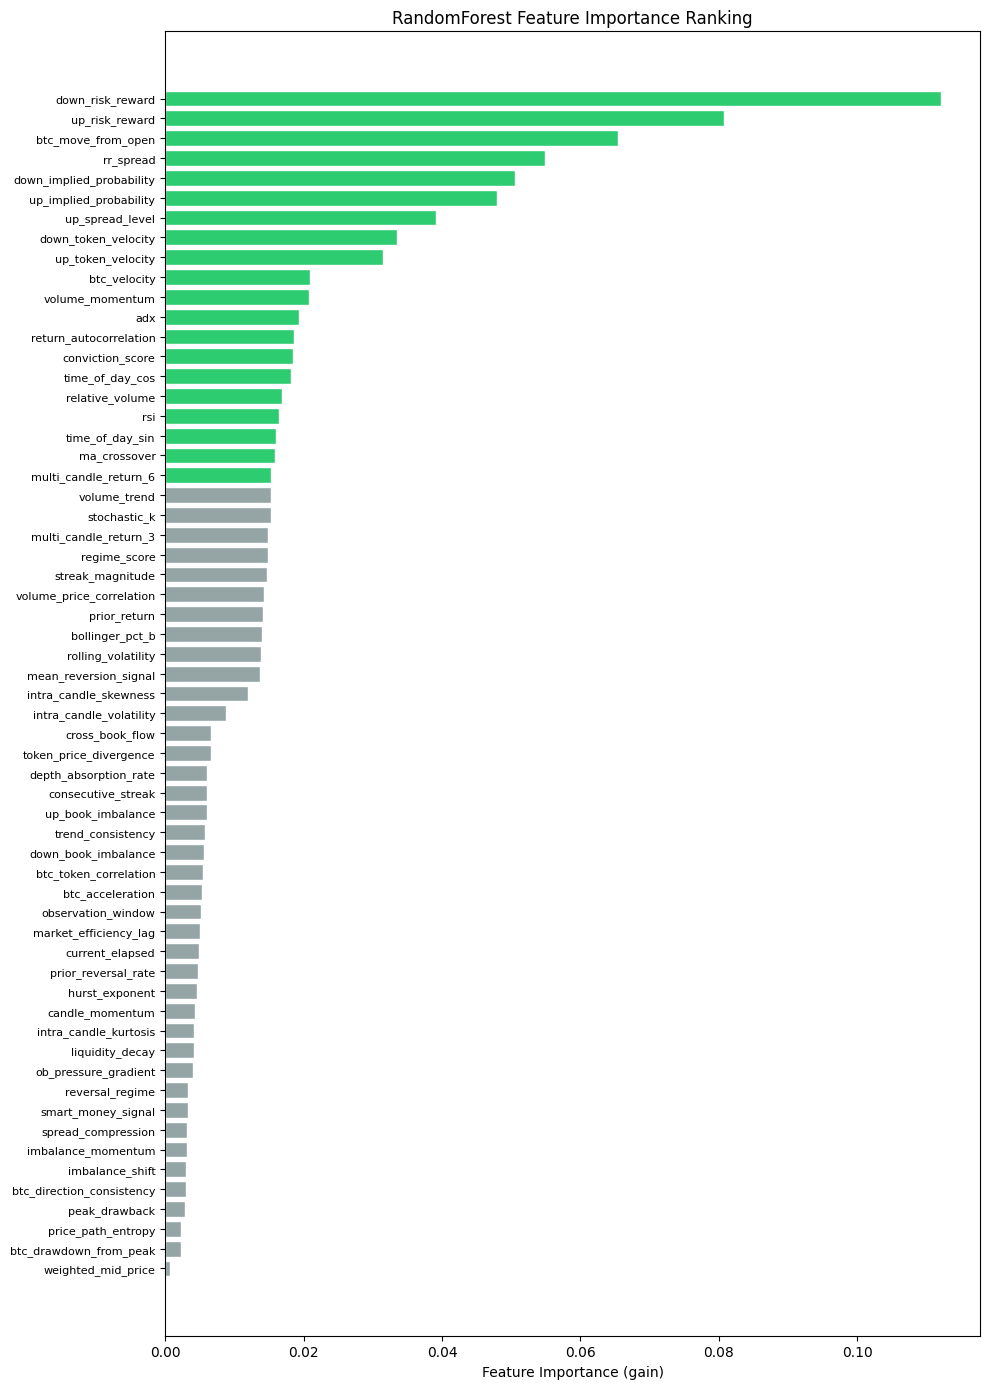

In [20]:
names = [f[0] for f in feat_imp]
imps = [f[1] for f in feat_imp]

fig, ax = plt.subplots(figsize=(10, 14))
colors = ["#2ecc71" if i < 20 else "#95a5a6" for i in range(len(names))]
ax.barh(range(len(names)), imps, color=colors, edgecolor="white")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("RandomForest Feature Importance Ranking")
plt.tight_layout()
plt.show()

## 4. Find optimal feature count

In [21]:
ranked_features = [name for name, _ in feat_imp]
ranked_indices = [all_feat_cols.index(name) for name in ranked_features]

top_n_results = []
print(f"{'Top N':<8} {'Snap Acc':>9}")
print("-" * 20)

for n in list(range(5, len(all_feat_cols) + 1, 5)) + [len(all_feat_cols)]:
    idx = ranked_indices[:n]
    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_train_all[:, idx], y_train)
    snap_acc = accuracy_score(y_val, rf.predict(X_val_all[:, idx]))
    top_n_results.append((n, snap_acc))
    print(f"  {n:<6} {snap_acc * 100:>8.1f}%")

best_n, best_snap = max(top_n_results, key=lambda x: x[1])
print(f"\nOptimal: top {best_n} features -> {best_snap * 100:.1f}% snapshot accuracy")
print(f"Baseline: {baseline_acc * 100:.1f}% (all {len(all_feat_cols)})")
print(f"Improvement: {(best_snap - baseline_acc) * 100:+.1f}%")

optimal_names = ranked_features[:best_n]
print(f"Optimal features: {optimal_names}")

Top N     Snap Acc
--------------------
  5          75.2%
  10         74.9%
  15         75.3%
  20         74.7%
  25         74.2%
  30         74.5%
  35         74.5%
  40         74.2%
  45         74.4%
  50         74.6%
  55         74.5%
  60         74.4%
  60         74.4%

Optimal: top 15 features -> 75.3% snapshot accuracy
Baseline: 74.8% (all 60)
Improvement: +0.5%
Optimal features: ['down_risk_reward', 'up_risk_reward', 'btc_move_from_open', 'rr_spread', 'down_implied_probability', 'up_implied_probability', 'up_spread_level', 'down_token_velocity', 'up_token_velocity', 'btc_velocity', 'volume_momentum', 'adx', 'return_autocorrelation', 'conviction_score', 'time_of_day_cos']


### Accuracy vs feature count

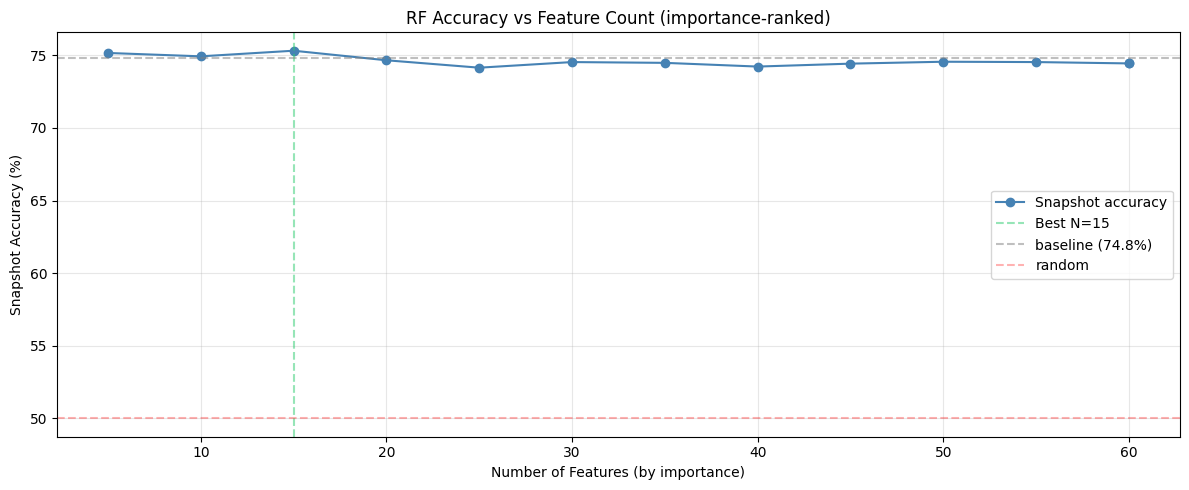

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
ns = [r[0] for r in top_n_results]
snap_accs = [r[1] * 100 for r in top_n_results]

ax.plot(ns, snap_accs, "o-", label="Snapshot accuracy", color="steelblue")
ax.axvline(best_n, color="#2ecc71", linestyle="--", alpha=0.5, label=f"Best N={best_n}")
ax.axhline(baseline_acc * 100, color="gray", linestyle="--", alpha=0.5, label=f"baseline ({baseline_acc * 100:.1f}%)")
ax.axhline(50, color="red", linestyle="--", alpha=0.3, label="random")
ax.set_xlabel("Number of Features (by importance)")
ax.set_ylabel("Snapshot Accuracy (%)")
ax.set_title("RF Accuracy vs Feature Count (importance-ranked)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evaluate optimal model

In [23]:
optimal_indices = ranked_indices[:best_n]
X_tr = X_train_all[:, optimal_indices]
X_va = X_val_all[:, optimal_indices]

rf_opt = RandomForestClassifier(**RF_PARAMS)
rf_opt.fit(X_tr, y_train)

opt_acc = accuracy_score(y_val, rf_opt.predict(X_va))
print(f"Optimal RF ({best_n} features): {opt_acc * 100:.1f}% snapshot accuracy")

print("\nTop 10 features (by importance):")
for i in range(min(10, best_n)):
    name, imp = feat_imp[i]
    print(f"  {i + 1:>2}. {name:<30} importance={imp:.4f}")

Optimal RF (15 features): 75.3% snapshot accuracy

Top 10 features (by importance):
   1. down_risk_reward               importance=0.1122
   2. up_risk_reward                 importance=0.0807
   3. btc_move_from_open             importance=0.0655
   4. rr_spread                      importance=0.0548
   5. down_implied_probability       importance=0.0506
   6. up_implied_probability         importance=0.0480
   7. up_spread_level                importance=0.0392
   8. down_token_velocity            importance=0.0334
   9. up_token_velocity              importance=0.0315
  10. btc_velocity                   importance=0.0210


## 6. Save optimal features

In [24]:
config = {
    "model": "random_forest",
    "features": optimal_names,
    "n_features": best_n,
    "accuracy": round(best_snap, 4),
    "selection_method": "importance_ranking",
    "hyperparameters": {k: v for k, v in RF_PARAMS.items() if k != "n_jobs"},
    "source": "data/latest_features.jsonl",
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_features_rf.json")
with open(out_path, "w") as f:
    _json.dump(config, f, indent=2)

print(f"Saved {config['n_features']} RF features to {out_path}")
print(f"Accuracy: {config['accuracy'] * 100:.2f}%")
print(f"Hyperparameters: {config['hyperparameters']}")
print(f"Features: {config['features']}")

Saved 15 RF features to ../../data/optimal_features_rf.json
Accuracy: 75.32%
Hyperparameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 20, 'random_state': 42}
Features: ['down_risk_reward', 'up_risk_reward', 'btc_move_from_open', 'rr_spread', 'down_implied_probability', 'up_implied_probability', 'up_spread_level', 'down_token_velocity', 'up_token_velocity', 'btc_velocity', 'volume_momentum', 'adx', 'return_autocorrelation', 'conviction_score', 'time_of_day_cos']


## Conclusion

Optimal RF features saved to `data/optimal_features_rf.json`.
Run `rf/02_export.ipynb` to export the model, then `rf/03_strategy.ipynb` for strategy discovery.
